In [1]:
import yfinance as yf
import pandas as pd
from pathlib import Path

# BIST30 tickers (yfinance requires .IS suffix)
BIST30_TICKERS = [
    "AKBNK.IS", "ARCLK.IS", "ASELS.IS", "BIMAS.IS", "CIMSA.IS",
    "EKGYO.IS", "EREGL.IS", "FROTO.IS", "GARAN.IS", "GUBRF.IS",
    "HALKB.IS", "ISCTR.IS", "KCHOL.IS", "KONTR.IS", "KRDMD.IS",
    "MGROS.IS", "ODAS.IS", "PETKM.IS", "PGSUS.IS", "SAHOL.IS",
    "SASA.IS", "SISE.IS", "TAVHL.IS", "TCELL.IS", "THYAO.IS",
    "TKFEN.IS", "TOASO.IS", "TUPRS.IS", "VAKBN.IS", "YKBNK.IS"
]

print(f"Total tickers: {len(BIST30_TICKERS)}")
print(BIST30_TICKERS[:5])

Total tickers: 30
['AKBNK.IS', 'ARCLK.IS', 'ASELS.IS', 'BIMAS.IS', 'CIMSA.IS']


In [2]:
!pip install pyarrow

In [3]:
raw_dir = Path("../data/raw/prices")
raw_dir.mkdir(parents=True, exist_ok=True)

all_data = {}
failed = []

for ticker in BIST30_TICKERS:
    try:
        df = yf.download(ticker, period="5y", auto_adjust=True, progress=False)
        if len(df) < 100:
            failed.append(ticker)
            continue
        df.to_parquet(raw_dir / f"{ticker.replace('.IS', '')}.parquet")
        all_data[ticker] = df
        print(f"✅ {ticker}: {len(df)} days")
    except Exception as e:
        failed.append(ticker)
        print(f"❌ {ticker}: {e}")

print(f"\nSuccess: {len(all_data)}, Failed: {failed}")

✅ AKBNK.IS: 1250 days
✅ ARCLK.IS: 1250 days
✅ ASELS.IS: 1250 days
✅ BIMAS.IS: 1250 days
✅ CIMSA.IS: 1250 days
✅ EKGYO.IS: 1250 days
✅ EREGL.IS: 1251 days
✅ FROTO.IS: 1251 days
✅ GARAN.IS: 1250 days
✅ GUBRF.IS: 1250 days
✅ HALKB.IS: 1250 days
✅ ISCTR.IS: 1250 days
✅ KCHOL.IS: 1250 days
✅ KONTR.IS: 1251 days
✅ KRDMD.IS: 1250 days
✅ MGROS.IS: 1250 days
✅ ODAS.IS: 1250 days
✅ PETKM.IS: 1250 days
✅ PGSUS.IS: 1251 days
✅ SAHOL.IS: 1250 days
✅ SASA.IS: 1251 days
✅ SISE.IS: 1250 days
✅ TAVHL.IS: 1250 days
✅ TCELL.IS: 1250 days
✅ THYAO.IS: 1250 days
✅ TKFEN.IS: 1251 days
✅ TOASO.IS: 1250 days
✅ TUPRS.IS: 1250 days
✅ VAKBN.IS: 1250 days
✅ YKBNK.IS: 1250 days

Success: 30, Failed: []


In [4]:
# Quick check - THYAO example
thyao = pd.read_parquet("../data/raw/prices/THYAO.parquet")

print("Shape:", thyao.shape)
print("Date range:", thyao.index[0].date(), "→", thyao.index[-1].date())
print("Missing values:\n", thyao.isnull().sum())
thyao.head()

Shape: (1250, 5)
Date range: 2021-04-29 → 2026-04-29
Missing values:
 Price   Ticker  
Close   THYAO.IS    0
High    THYAO.IS    0
Low     THYAO.IS    0
Open    THYAO.IS    0
Volume  THYAO.IS    0
dtype: int64


Price,Close,High,Low,Open,Volume
Ticker,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS
Date,,,,,
2021-04-29,11.703073,11.790992,11.615154,11.771455,31262763
2021-04-30,11.947293,12.044982,11.673766,11.683535,77606295
2021-05-03,12.621344,12.650650,12.015676,12.044982,99132973
2021-05-04,12.328279,12.787414,12.328279,12.777645,103271085
2021-05-05,12.308741,12.416198,12.162207,12.386891,58791952


In [5]:
summary = []
for ticker in BIST30_TICKERS:
    name = ticker.replace('.IS', '')
    try:
        df = pd.read_parquet(f"../data/raw/prices/{name}.parquet")
        summary.append({
            "ticker": name,
            "n_days": len(df),
            "start": df.index[0].date(),
            "end": df.index[-1].date(),
            "missing": df.isnull().sum().sum()
        })
    except:
        pass

summary_df = pd.DataFrame(summary).sort_values("n_days")
print(f"Total stocks: {len(summary_df)}")
print(f"Any missing values: {summary_df['missing'].sum()}")
summary_df

Total stocks: 30
Any missing values: 0


,ticker,n_days,start,end,missing
0,AKBNK,1250,2021-04-29,2026-04-29,0
27,TUPRS,1250,2021-04-29,2026-04-29,0
26,TOASO,1250,2021-04-29,2026-04-29,0
24,THYAO,1250,2021-04-29,2026-04-29,0
23,TCELL,1250,2021-04-29,2026-04-29,0
22,TAVHL,1250,2021-04-29,2026-04-29,0
21,SISE,1250,2021-04-29,2026-04-29,0
19,SAHOL,1250,2021-04-29,2026-04-29,0
17,PETKM,1250,2021-04-29,2026-04-29,0
16,ODAS,1250,2021-04-29,2026-04-29,0


let's making eda !!

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load all closing prices into one dataframe
close_prices = {}
for ticker in BIST30_TICKERS:
    name = ticker.replace('.IS', '')
    df = pd.read_parquet(f"../data/raw/prices/{name}.parquet")
    close_prices[name] = df["Close"].iloc[:, 0]  # ilk kolonu al

close_df = pd.DataFrame(close_prices)
print("Shape:", close_df.shape)
close_df.head()

Shape: (1251, 30)


,AKBNK,ARCLK,ASELS,BIMAS,CIMSA,EKGYO,EREGL,FROTO,GARAN,GUBRF,...,SASA,SISE,TAVHL,TCELL,THYAO,TKFEN,TOASO,TUPRS,VAKBN,YKBNK
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-29,3.893652,33.083691,7.367405,56.752541,2.677655,1.642752,8.268424,13.194818,5.831885,61.599998,...,0.977813,6.783925,20.680000,12.729623,11.703073,14.543149,21.672695,8.097633,3.42,1.802897
2021-04-30,3.893652,32.497639,7.357595,55.555946,2.747593,1.633775,8.173977,13.090569,5.815752,60.549999,...,0.960640,6.866210,21.520000,12.487103,11.947293,14.181774,21.499775,8.079219,3.42,1.802897
2021-05-03,3.981420,32.554348,7.411551,56.196980,2.854999,1.660705,8.139631,12.949088,5.944812,61.799999,...,0.979960,7.067350,23.200001,12.512347,12.621344,14.349242,21.298035,8.364637,3.46,1.820068
2021-05-04,3.941525,31.949390,7.313449,55.299541,2.822527,1.642752,8.435853,12.576776,5.864149,60.299999,...,0.960103,6.985065,22.879999,12.453446,12.328279,14.507893,21.038654,8.300188,3.40,1.794312
2021-05-05,3.941525,31.571295,7.313449,55.897839,3.057321,1.653381,8.345699,13.179926,5.848017,60.799999,...,0.942393,6.975923,22.820000,12.445031,12.308741,14.190589,20.721634,8.406071,3.40,1.785727


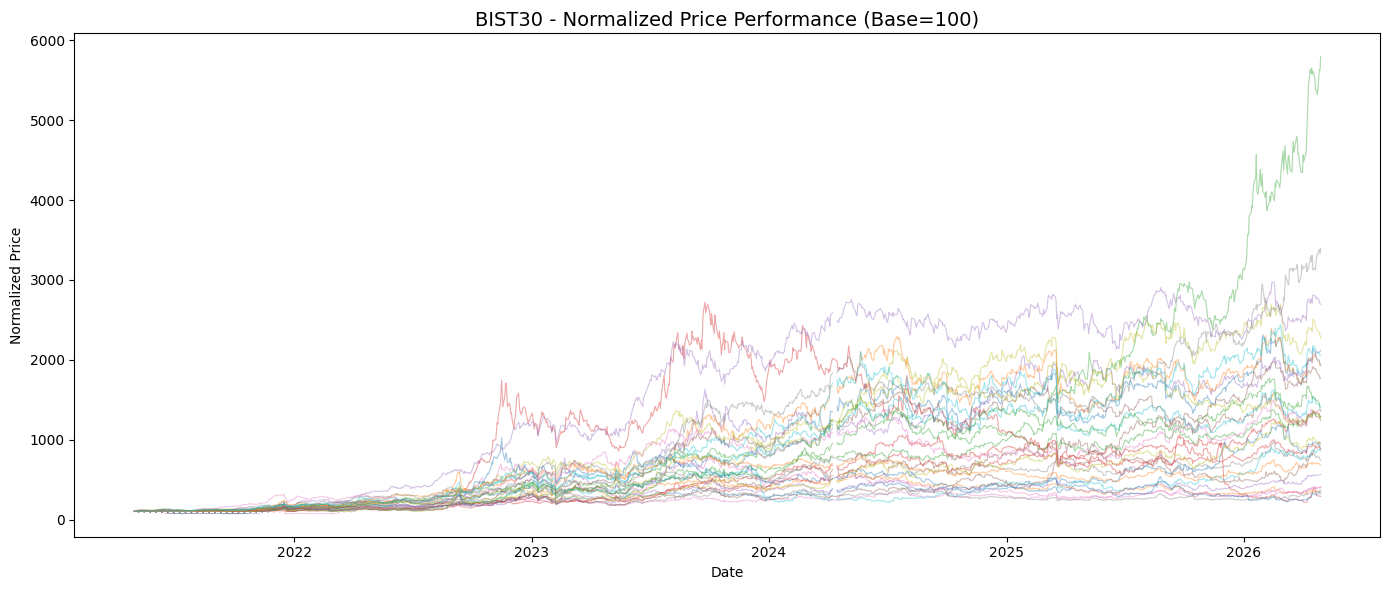

In [9]:
# Normalize prices to 100 (to compare performance across stocks)
normalized = close_df.div(close_df.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], alpha=0.4, linewidth=0.8)

plt.title("BIST30 - Normalized Price Performance (Base=100)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.axhline(y=100, color='white', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

## BIST30 Normalized Price Performance

All stocks normalized to base 100 (starting price = 100) to enable fair comparison 
across different price levels.

**Key observations:**
- 2021–2022: Relatively flat movement across all stocks
- 2022 onwards: Sharp nominal price increases driven by Turkey's high inflation environment
- Top performer reached ~5800x base — extreme outlier likely driven by sector-specific catalysts
- Most stocks clustered between 500–2000x, reflecting broad market inflation

In [10]:
# Daily returns
# This will be the basis of anomaly detection 
returns = close_df.pct_change().dropna()

print("Returns shape:", returns.shape)
print("\nDescriptive stats:")
returns.describe().round(4)

Returns shape: (1248, 30)

Descriptive stats:


,AKBNK,ARCLK,ASELS,BIMAS,CIMSA,EKGYO,EREGL,FROTO,GARAN,GUBRF,...,SASA,SISE,TAVHL,TCELL,THYAO,TKFEN,TOASO,TUPRS,VAKBN,YKBNK
count,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,...,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000,1248.0000
mean,0.0028,0.0013,0.0037,0.0024,0.0029,0.0025,0.0015,0.0019,0.0029,0.0022,...,0.0015,0.0019,0.0025,0.0021,0.0030,0.0023,0.0025,0.0032,0.0023,0.0028
std,0.0297,0.0256,0.0292,0.0240,0.0296,0.0307,0.0254,0.0251,0.0284,0.0325,...,0.0334,0.0246,0.0270,0.0256,0.0261,0.0320,0.0283,0.0258,0.0300,0.0299
min,-0.0999,-0.0998,-0.1000,-0.0998,-0.1000,-0.1000,-0.0998,-0.0998,-0.0999,-0.1000,...,-0.1000,-0.0999,-0.0998,-0.1000,-0.0998,-0.1000,-0.1000,-0.0998,-0.0998,-0.1000
25%,-0.0134,-0.0133,-0.0142,-0.0113,-0.0150,-0.0139,-0.0123,-0.0126,-0.0128,-0.0151,...,-0.0179,-0.0125,-0.0139,-0.0123,-0.0125,-0.0140,-0.0145,-0.0116,-0.0135,-0.0137
50%,0.0014,0.0006,0.0017,0.0016,0.0013,0.0017,0.0000,0.0005,0.0007,0.0004,...,-0.0017,0.0006,0.0020,0.0011,0.0009,0.0017,0.0017,0.0008,0.0009,0.0009
75%,0.0174,0.0140,0.0191,0.0158,0.0179,0.0188,0.0145,0.0156,0.0164,0.0180,...,0.0169,0.0149,0.0172,0.0160,0.0161,0.0184,0.0180,0.0168,0.0166,0.0185
max,0.1803,0.1873,0.2201,0.1253,0.1960,0.2040,0.1594,0.1708,0.1774,0.2217,...,0.1899,0.1692,0.1941,0.1852,0.2165,0.1904,0.2103,0.1793,0.1791,0.1535
